# Predecir backbone con la GNN

## Setup

In [9]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from predict import predict_backbone

## Instancia

In [10]:
cnf_path = "../data/satlib/random_3sat/uf100-01.cnf"
assert os.path.exists(cnf_path), cnf_path

## Predecir

Devuelve un dict `{variable: score}`.

In [11]:
scores = predict_backbone(cnf_path)

print(f"variables predichas: {len(scores)}")
print(f"rango de score: min={min(scores.values()):.4f}  max={max(scores.values()):.4f}")

variables predichas: 100
rango de score: min=0.0094  max=0.9886


In [12]:
scores

{26: 0.3831480145454407,
 99: 0.8116191029548645,
 7: 0.3348485827445984,
 90: 0.9169024229049683,
 84: 0.13856162130832672,
 94: 0.9814117550849915,
 74: 0.20133177936077118,
 31: 0.9418078660964966,
 5: 0.014016443863511086,
 61: 0.9430325031280518,
 29: 0.011175048537552357,
 16: 0.21926066279411316,
 10: 0.5887368321418762,
 9: 0.5708044171333313,
 41: 0.5927676558494568,
 98: 0.9293951392173767,
 30: 0.1612446904182434,
 46: 0.8848789930343628,
 43: 0.12526364624500275,
 78: 0.9534987211227417,
 67: 0.5918664336204529,
 85: 0.17730750143527985,
 82: 0.5610252022743225,
 22: 0.21726897358894348,
 69: 0.009419710375368595,
 57: 0.8912844657897949,
 77: 0.10416602343320847,
 40: 0.6327371001243591,
 12: 0.9886394739151001,
 34: 0.9506136178970337,
 13: 0.8848962783813477,
 86: 0.46176856756210327,
 49: 0.030274711549282074,
 54: 0.7549243569374084,
 88: 0.07782384753227234,
 4: 0.3380833566188812,
 21: 0.6999582052230835,
 75: 0.1583734154701233,
 95: 0.33532950282096863,
 14: 0.7383

## Variables más probablemente backbone

In [13]:
confidence = lambda x: abs(x - 0.5)         
phase = lambda x: "+" if x >= 0.5 else "-"  

ranked = sorted(scores.items(), key=lambda kv: confidence(kv[1]), reverse=True)

print("top-10:")
for var, score in ranked[:10]:
    print(f"  x{var:<3}  {score:.4f}  fase {phase(score)}  conf {confidence(score):.3f}")

top-10:
  x69   0.0094  fase -  conf 0.491
  x29   0.0112  fase -  conf 0.489
  x12   0.9886  fase +  conf 0.489
  x5    0.0140  fase -  conf 0.486
  x60   0.0163  fase -  conf 0.484
  x94   0.9814  fase +  conf 0.481
  x59   0.0271  fase -  conf 0.473
  x48   0.9698  fase +  conf 0.470
  x49   0.0303  fase -  conf 0.470
  x97   0.0309  fase -  conf 0.469


## Histograma de los scores

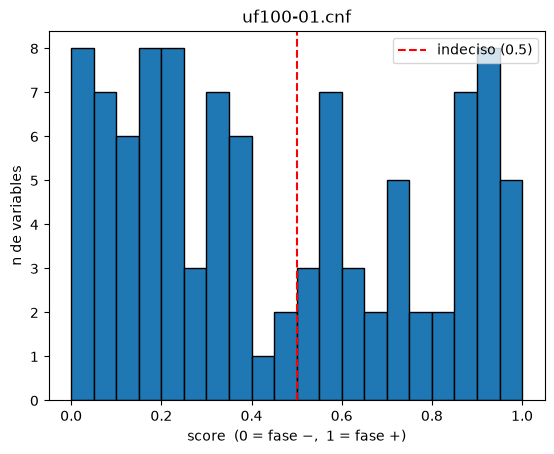

In [15]:
import matplotlib.pyplot as plt

plt.hist(list(scores.values()), bins=20, range=(0, 1), edgecolor="black")
plt.axvline(0.5, color="red", linestyle="--", label="indeciso (0.5)")
plt.xlabel("score  (0 = fase −,  1 = fase +)")
plt.ylabel("n de variables")
plt.title(os.path.basename(cnf_path))
plt.legend()
plt.show()

## Calibración vs. proporción de backbone (CBS)
A mayor backbone el modelo está menos confiado (puede ser...)

In [20]:
cbs_dir = "../data/satlib/cbs_backbone_controlled"
rows = []
for b in [10, 30, 50, 70, 90]:
    f = f"{cbs_dir}/CBS_k3_n100_m403_b{b}_0.cnf"
    if not os.path.exists(f):
        print(f"b{b}: (falta)"); continue
    s = list(predict_backbone(f).values())
    n = len(s)
    polar = 100 * sum(abs(x - 0.5) > 0.4 for x in s) / n
    mid = 100 * sum(abs(x - 0.5) < 0.1 for x in s) / n
    rows.append((b, polar, mid))
    print(f"b{b:>2}: polarizadas={polar:3.0f}%  indecisas={mid:3.0f}%")

b10: polarizadas= 34%  indecisas= 12%
b30: polarizadas= 30%  indecisas= 14%
b50: polarizadas= 25%  indecisas= 21%
b70: polarizadas= 23%  indecisas= 19%
b90: polarizadas= 14%  indecisas= 28%


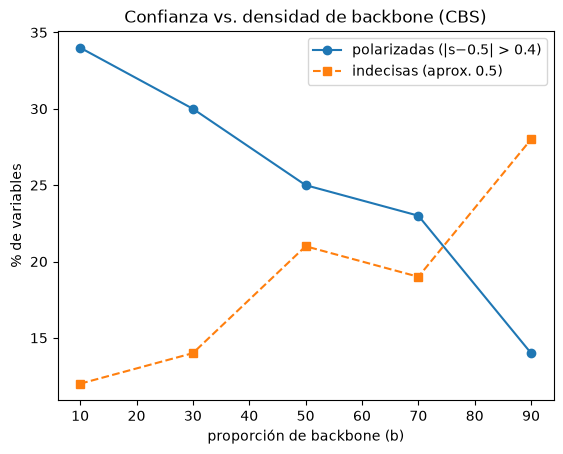

In [21]:
if rows:
    bs, polar_pct, mid_pct = zip(*rows)
    plt.plot(bs, polar_pct, "o-", label="polarizadas (|s−0.5| > 0.4)")
    plt.plot(bs, mid_pct, "s--", label="indecisas (aprox. 0.5)")
    plt.xlabel("proporción de backbone (b)")
    plt.ylabel("% de variables")
    plt.title("Confianza vs. densidad de backbone (CBS)")
    plt.legend()
    plt.show()